# 可视化 notebook（修复版）

本 notebook 用于基于已保存的模型选择结果，重建最终模型并绘制：

1. **1×3 parity 图（SCI 风格修复版）**
   - `(a)(b)(c)` 放在图外
   - 主散点图为正方形
   - 散点带清晰描边
   - 指标文本框放在右上空白区域，不遮挡数据

2. **1×3 SHAP 极坐标蜂巢图**
   - 画法参考你提供的示例
   - 使用当前结果文件重建后的模型与当前数据
   - 共享 colorbar，导出 PNG / PDF / SVG

> 使用前请确认：
> - `df_dev.xlsx`
> - `df_test.xlsx`
> - `model_selection/stage2_final_tuning/final_best_params.json`
> - `model_selection/stage2_final_tuning/stage2_final_tuning_results.xlsx`

都在当前工作目录或你指定的目录下。


In [1]:

# ============================================================
# Cell 1：导入依赖
# ============================================================
import os
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Patch
from matplotlib.transforms import offset_copy

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False
    XGBRegressor = None

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")


In [2]:

# ============================================================
# Cell 2：路径与全局参数
# ============================================================
DEV_PATH = Path("df_dev.xlsx")
TEST_PATH = Path("df_test.xlsx")

# 这里按你当前的目录名设置
RESULT_ROOT = Path("model_selection")
STAGE2_DIR = RESULT_ROOT / "stage2_final_tuning"

BEST_PARAMS_JSON = STAGE2_DIR / "final_best_params.json"
STAGE2_RESULT_XLSX = STAGE2_DIR / "stage2_final_tuning_results.xlsx"

OUTPUT_DIR = RESULT_ROOT / "visualization_outputs"
PARITY_DIR = OUTPUT_DIR / "parity"
SHAP_DIR = OUTPUT_DIR / "shap"
PARITY_DIR.mkdir(parents=True, exist_ok=True)
SHAP_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = [
    'Si', 'Fe', 'Cu', 'Mn', 'Mg', 'Cr', 'Zn', 'V', 'Ti', 'Zr',
    'Ni', 'Be', 'Sc', 'Tsol', 'Tage', 'tage'
]
TARGETS = ['YS', 'UTS', 'El']

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 120,
    'savefig.dpi': 600,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    'savefig.bbox': 'tight',
})

print("当前设备：", DEVICE)
print("工作目录：", Path.cwd())
print("开发集：", DEV_PATH.resolve())
print("测试集：", TEST_PATH.resolve())
print("结果目录：", RESULT_ROOT.resolve())
print("最佳参数文件：", BEST_PARAMS_JSON.resolve())
print("阶段2结果表：", STAGE2_RESULT_XLSX.resolve())


当前设备： cuda
工作目录： e:\al_alloy_fast
开发集： E:\al_alloy_fast\df_dev.xlsx
测试集： E:\al_alloy_fast\df_test.xlsx
结果目录： E:\al_alloy_fast\model_selection
最佳参数文件： E:\al_alloy_fast\model_selection\stage2_final_tuning\final_best_params.json
阶段2结果表： E:\al_alloy_fast\model_selection\stage2_final_tuning\stage2_final_tuning_results.xlsx


In [3]:

# ============================================================
# Cell 3：读取数据与结果文件
# ============================================================
assert DEV_PATH.exists(), f"未找到开发集文件：{DEV_PATH}"
assert TEST_PATH.exists(), f"未找到测试集文件：{TEST_PATH}"
assert BEST_PARAMS_JSON.exists(), f"未找到最佳参数文件：{BEST_PARAMS_JSON}"
assert STAGE2_RESULT_XLSX.exists(), f"未找到阶段2结果表：{STAGE2_RESULT_XLSX}"

df_dev = pd.read_excel(DEV_PATH)
df_test = pd.read_excel(TEST_PATH)

missing_in_dev = [c for c in FEATURES + TARGETS if c not in df_dev.columns]
missing_in_test = [c for c in FEATURES + TARGETS if c not in df_test.columns]
assert len(missing_in_dev) == 0, f"开发集缺少列：{missing_in_dev}"
assert len(missing_in_test) == 0, f"测试集缺少列：{missing_in_test}"

with open(BEST_PARAMS_JSON, "r", encoding="utf-8") as f:
    final_best_params = json.load(f)

stage2_results_df = pd.read_excel(STAGE2_RESULT_XLSX)
display(stage2_results_df)


,target,selected_model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,best_value_MAE
0,YS,GBR,25.384454,1.926324,36.761422,3.210121,0.892047,0.026321,25.384454
1,UTS,ETR,24.819343,2.405933,33.664388,3.315897,0.886447,0.035475,24.819343
2,El,GBR,1.890872,0.432320,3.014018,1.033711,0.758984,0.108484,1.890872


In [4]:

# ============================================================
# Cell 4：工具函数
# ============================================================
def calc_reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return {
        'R2': float(r2_score(y_true, y_pred)),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }

def safe_std(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def nice_lim(values_true, values_pred, pad_ratio=0.06):
    vals = np.concatenate([np.asarray(values_true).ravel(), np.asarray(values_pred).ravel()])
    vmin = np.min(vals)
    vmax = np.max(vals)
    span = vmax - vmin
    if span == 0:
        span = max(abs(vmin), 1.0) * 0.1
    pad = span * pad_ratio
    return vmin - pad, vmax + pad

def shorten_feature_name(name):
    mapping = {
        'Tsol': 'Tsol',
        'Tage': 'Tage',
        'tage': 'tage'
    }
    return mapping.get(str(name), str(name))


In [5]:

# ============================================================
# Cell 5：DNN 回归器
# ============================================================
class _DNNNet(nn.Module):
    def __init__(self, input_dim, hidden_layers=(64, 32), activation='relu', dropout=0.0):
        super().__init__()
        act_map = {
            'relu': nn.ReLU(),
            'gelu': nn.GELU(),
            'elu': nn.ELU(),
            'tanh': nn.Tanh(),
            'leaky_relu': nn.LeakyReLU(0.1),
        }
        layers = []
        in_dim = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(in_dim, h))
            layers.append(act_map.get(activation, nn.ReLU()).__class__())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        input_dim=None,
        hidden_layers=(64, 32),
        activation='relu',
        dropout=0.0,
        lr=1e-3,
        batch_size=32,
        epochs=200,
        patience=20,
        weight_decay=0.0,
        random_state=42,
        verbose=False,
        use_gpu=True,
    ):
        self.input_dim = input_dim
        self.hidden_layers = hidden_layers
        self.activation = activation
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.weight_decay = weight_decay
        self.random_state = random_state
        self.verbose = verbose
        self.use_gpu = use_gpu

    def _set_seed(self):
        np.random.seed(self.random_state)
        random.seed(self.random_state)
        torch.manual_seed(self.random_state)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.random_state)

    def fit(self, X, y):
        self._set_seed()
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32).reshape(-1, 1)

        self.scaler_ = StandardScaler()
        Xs = self.scaler_.fit_transform(X).astype(np.float32)

        device = torch.device('cuda' if (self.use_gpu and torch.cuda.is_available()) else 'cpu')
        self.model_ = _DNNNet(
            input_dim=self.input_dim if self.input_dim is not None else X.shape[1],
            hidden_layers=self.hidden_layers,
            activation=self.activation,
            dropout=self.dropout
        ).to(device)

        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        criterion = nn.MSELoss()

        Xt = torch.tensor(Xs, dtype=torch.float32)
        yt = torch.tensor(y, dtype=torch.float32)
        dataset = TensorDataset(Xt, yt)
        loader = DataLoader(dataset, batch_size=min(self.batch_size, len(dataset)), shuffle=True)

        best_loss = np.inf
        best_state = None
        no_improve = 0

        self.model_.train()
        for epoch in range(self.epochs):
            epoch_losses = []
            for xb, yb in loader:
                xb = xb.to(device)
                yb = yb.to(device)

                optimizer.zero_grad()
                pred = self.model_(xb)
                loss = criterion(pred, yb)
                loss.backward()
                optimizer.step()
                epoch_losses.append(loss.item())

            mean_loss = float(np.mean(epoch_losses)) if epoch_losses else np.inf
            if mean_loss < best_loss - 1e-8:
                best_loss = mean_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model_.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1

            if no_improve >= self.patience:
                break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.model_.eval()
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        Xs = self.scaler_.transform(X).astype(np.float32)
        device = torch.device('cuda' if (self.use_gpu and torch.cuda.is_available()) else 'cpu')
        self.model_.to(device)
        self.model_.eval()
        with torch.no_grad():
            preds = self.model_(torch.tensor(Xs, dtype=torch.float32).to(device)).cpu().numpy().ravel()
        return preds


In [6]:

# ============================================================
# Cell 6：模型构建函数
# ============================================================
def build_model(model_name, params, input_dim=None):
    if model_name == 'GBR':
        return GradientBoostingRegressor(random_state=RANDOM_SEED, **params)

    if model_name == 'XGBR':
        if not XGB_AVAILABLE:
            raise RuntimeError("当前环境未安装 xgboost，无法使用 XGBR。")
        xgb_params = dict(params)
        xgb_params.update({
            'random_state': RANDOM_SEED,
            'verbosity': 0,
            'n_jobs': -1,
            'tree_method': 'hist',
        })
        try:
            if torch.cuda.is_available():
                xgb_params['device'] = 'cuda'
            return XGBRegressor(**xgb_params)
        except Exception:
            xgb_params.pop('device', None)
            return XGBRegressor(**xgb_params)

    if model_name == 'ETR':
        return ExtraTreesRegressor(random_state=RANDOM_SEED, n_jobs=-1, **params)

    if model_name == 'RFR':
        return RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **params)

    if model_name == 'KNNR':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsRegressor(**params))
        ])

    if model_name == 'DNNR_rand':
        return DNNRegressor(
            input_dim=input_dim,
            random_state=RANDOM_SEED,
            verbose=False,
            use_gpu=True,
            **params
        )

    raise ValueError(f"不支持的模型名称：{model_name}")


In [7]:

# ============================================================
# Cell 7：根据保存结果重建最终模型
# ============================================================
selected_models = dict(zip(stage2_results_df['target'], stage2_results_df['selected_model']))
final_models = {}

for target in TARGETS:
    model_name = selected_models[target]
    best_params = final_best_params[target]

    df_dev_t = df_dev.dropna(subset=[target]).reset_index(drop=True)
    df_test_t = df_test.dropna(subset=[target]).reset_index(drop=True)

    X_dev = df_dev_t[FEATURES].values
    y_dev = df_dev_t[target].values
    X_test = df_test_t[FEATURES].values
    y_test = df_test_t[target].values

    model = build_model(model_name, best_params, input_dim=X_dev.shape[1])
    model.fit(X_dev, y_dev)
    y_test_pred = model.predict(X_test)

    final_models[target] = {
        'model_name': model_name,
        'best_params': best_params,
        'model': model,
        'X_dev': X_dev,
        'y_dev': y_dev,
        'X_test': X_test,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'df_dev': df_dev_t,
        'df_test': df_test_t,
    }

    print(f"{target}: {model_name} rebuilt.")


YS: GBR rebuilt.
UTS: ETR rebuilt.
El: GBR rebuilt.


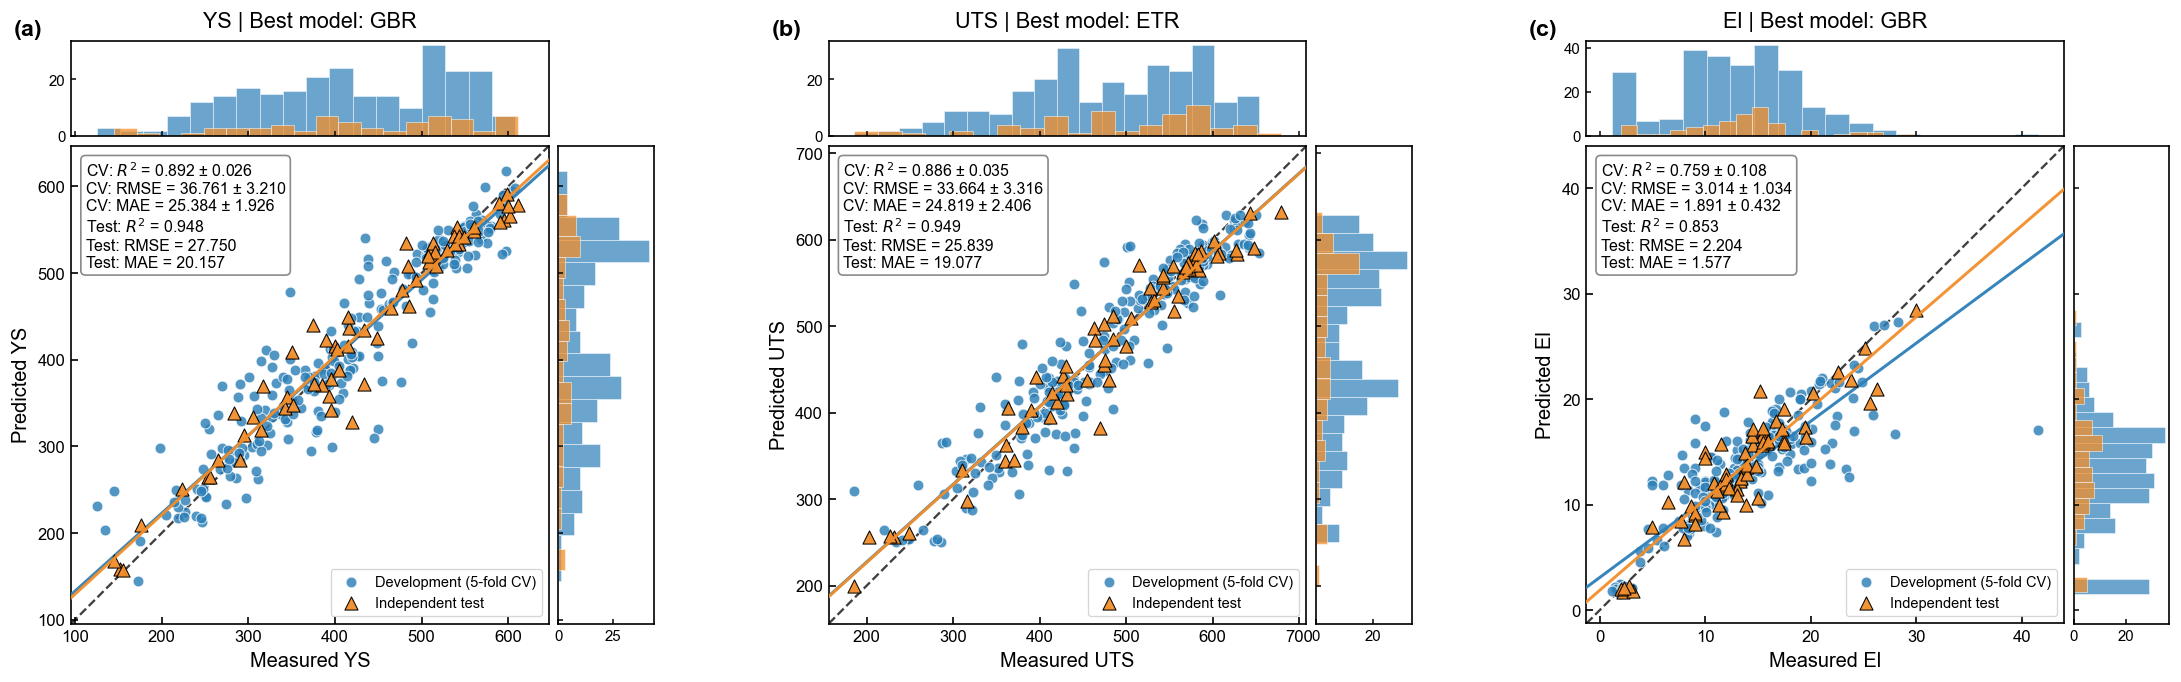

,target,model,cv_R2_mean,cv_R2_std,cv_RMSE_mean,cv_RMSE_std,cv_MAE_mean,cv_MAE_std,test_R2,test_RMSE,test_MAE
0,YS,GBR,0.892047,0.026321,36.761422,3.210121,25.384454,1.926324,0.948382,27.750500,20.157329
1,UTS,ETR,0.886447,0.035475,33.664388,3.315897,24.819343,2.405933,0.949372,25.839405,19.077107
2,El,GBR,0.758984,0.108484,3.014018,1.033711,1.890872,0.432320,0.852942,2.203571,1.577120


In [23]:

# ============================================================
# Cell 8：1×3 parity 图
# ============================================================
from mpl_toolkits.axes_grid1 import make_axes_locatable
TARGET_ORDER = ['YS', 'UTS', 'El']
PANEL_LABELS = ['(a)', '(b)', '(c)']
FINAL_CV_SPLITS = 5

fig = plt.figure(figsize=(18.5, 6.8))
outer = GridSpec(1, 3, figure=fig, wspace=0.30)

parity_summary_rows = []

for i, target in enumerate(TARGET_ORDER):
    res = final_models[target]
    model_name = res['model_name']
    best_params = res['best_params']

    X_dev = res['X_dev']
    y_dev = res['y_dev']
    X_test = res['X_test']
    y_test = res['y_test']
    test_pred = res['y_test_pred']

    cv = KFold(n_splits=FINAL_CV_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    model_for_cv = build_model(model_name, best_params, input_dim=X_dev.shape[1])

    cv_pred = cross_val_predict(
        model_for_cv,
        X_dev,
        y_dev,
        cv=cv,
        n_jobs=-1 if model_name != 'DNNR_rand' else 1
    )

    scoring = {
        'r2': 'r2',
        'neg_mae': 'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error'
    }
    cv_scores = cross_validate(
        model_for_cv,
        X_dev,
        y_dev,
        cv=cv,
        scoring=scoring,
        n_jobs=-1 if model_name != 'DNNR_rand' else 1,
        return_train_score=False
    )

    cv_r2_mean = np.mean(cv_scores['test_r2'])
    cv_r2_std = safe_std(cv_scores['test_r2'])
    cv_mae_mean = -np.mean(cv_scores['test_neg_mae'])
    cv_mae_std = safe_std(-cv_scores['test_neg_mae'])
    cv_rmse_mean = -np.mean(cv_scores['test_neg_rmse'])
    cv_rmse_std = safe_std(-cv_scores['test_neg_rmse'])
    test_metrics = calc_reg_metrics(y_test, test_pred)

    parity_summary_rows.append({
        'target': target,
        'model': model_name,
        'cv_R2_mean': cv_r2_mean,
        'cv_R2_std': cv_r2_std,
        'cv_RMSE_mean': cv_rmse_mean,
        'cv_RMSE_std': cv_rmse_std,
        'cv_MAE_mean': cv_mae_mean,
        'cv_MAE_std': cv_mae_std,
        'test_R2': test_metrics['R2'],
        'test_RMSE': test_metrics['RMSE'],
        'test_MAE': test_metrics['MAE'],
    })

   
    PAD = 0.08    # 主图和边际图的距离（上下左右完全一样）
    SIZE = "20%"  # 边际图大小

    ax_main = fig.add_subplot(outer[i])
    divider = make_axes_locatable(ax_main)

    ax_top = divider.append_axes("top", size=SIZE, pad=PAD, sharex=ax_main)
    ax_right = divider.append_axes("right", size=SIZE, pad=PAD, sharey=ax_main)

    xmin, xmax = nice_lim(np.concatenate([y_dev, y_test]), np.concatenate([cv_pred, test_pred]))

    ax_main.scatter(
        y_dev, cv_pred,
        s=42, alpha=0.82, marker='o',
        facecolors='#2C7FB8',
        edgecolors='white',
        linewidths=0.55,
        label='Development (5-fold CV)',
        zorder=3
    )
    ax_main.scatter(
        y_test, test_pred,
        s=62, alpha=0.95, marker='^',
        facecolors='#F28E2B',
        edgecolors='black',
        linewidths=0.65,
        label='Independent test',
        zorder=4
    )

    ax_main.plot([xmin, xmax], [xmin, xmax], '--', lw=1.4, color='black', alpha=0.75, zorder=2)

    if len(y_dev) >= 2:
        coef_dev = np.polyfit(y_dev, cv_pred, 1)
        xline = np.linspace(xmin, xmax, 200)
        ax_main.plot(xline, coef_dev[0] * xline + coef_dev[1], lw=1.8, color='#2C7FB8', alpha=0.95, zorder=3)

    if len(y_test) >= 2:
        coef_test = np.polyfit(y_test, test_pred, 1)
        xline = np.linspace(xmin, xmax, 200)
        ax_main.plot(xline, coef_test[0] * xline + coef_test[1], lw=1.8, color='#F28E2B', alpha=0.95, zorder=4)

    bins_x = 18 if len(y_dev) + len(y_test) > 80 else 12
    bins_y = 18 if len(cv_pred) + len(test_pred) > 80 else 12

    ax_top.hist(y_dev, bins=bins_x, color='#2C7FB8', alpha=0.70, edgecolor='white', linewidth=0.4)
    ax_top.hist(y_test, bins=bins_x, color='#F28E2B', alpha=0.75, edgecolor='white', linewidth=0.4)

    ax_right.hist(cv_pred, bins=bins_y, orientation='horizontal', color='#2C7FB8', alpha=0.70, edgecolor='white', linewidth=0.4)
    ax_right.hist(test_pred, bins=bins_y, orientation='horizontal', color='#F28E2B', alpha=0.75, edgecolor='white', linewidth=0.4)

    ax_main.set_xlim(xmin, xmax)
    ax_main.set_ylim(xmin, xmax)
    ax_top.set_xlim(xmin, xmax)
    ax_right.set_ylim(xmin, xmax)

    ax_main.set_xlabel(f'Measured {target}', fontsize=12)
    ax_main.set_ylabel(f'Predicted {target}', fontsize=12)

    ax_main.set_aspect('equal', adjustable='box')

    ax_top.tick_params(axis='x', labelbottom=False)
    ax_right.tick_params(axis='y', labelleft=False)

    ax_main.tick_params(direction='in', length=4, width=1.0, labelsize=10)
    ax_top.tick_params(direction='in', length=3, width=0.9, labelsize=9)
    ax_right.tick_params(direction='in', length=3, width=0.9, labelsize=9)

    for ax in [ax_main, ax_top, ax_right]:
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

    ax_top.set_title(f'{target} | Best model: {model_name}', fontsize=13, pad=8)

    metrics_text = (
        f'CV: $R^2$ = {cv_r2_mean:.3f} ± {cv_r2_std:.3f}\n'
        f'CV: RMSE = {cv_rmse_mean:.3f} ± {cv_rmse_std:.3f}\n'
        f'CV: MAE = {cv_mae_mean:.3f} ± {cv_mae_std:.3f}\n'
        f'Test: $R^2$ = {test_metrics["R2"]:.3f}\n'
        f'Test: RMSE = {test_metrics["RMSE"]:.3f}\n'
        f'Test: MAE = {test_metrics["MAE"]:.3f}'
    )

    leg = ax_main.legend(frameon=True, fontsize=8.8, loc='lower right', borderpad=0.4, handletextpad=0.6)
    leg.get_frame().set_linewidth(0.8)

    ax_main.text(
    0.03, 0.97, metrics_text,
    transform=ax_main.transAxes,
    ha='left', va='top',
    fontsize=9.5,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.92)
)

    ax_top.text(
    -0.12, 1.22, PANEL_LABELS[i],
    transform=ax_top.transAxes,
    ha='left', va='top',
    fontsize=14, fontweight='bold',
    clip_on=False
)

fig.subplots_adjust(left=0.045, right=0.99, top=0.90, bottom=0.12, wspace=0.30)

plt.savefig(PARITY_DIR / 'best_models_parity_1x3_sci.png', dpi=600, bbox_inches='tight')
plt.savefig(PARITY_DIR / 'best_models_parity_1x3_sci.svg', bbox_inches='tight')
plt.savefig(PARITY_DIR / 'best_models_parity_1x3_sci.pdf', bbox_inches='tight')
plt.show()

parity_summary_df = pd.DataFrame(parity_summary_rows)
parity_summary_df.to_excel(PARITY_DIR / 'best_models_parity_1x3_summary.xlsx', index=False)
display(parity_summary_df)


In [9]:

# ============================================================
# Cell 9：导入 SHAP
# ============================================================
try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print("未能导入 shap：", e)
    print("请先安装 shap，例如：pip install shap")

assert SHAP_AVAILABLE, "当前环境未安装 shap，无法继续执行 SHAP 分析。"


In [10]:

# ============================================================
# Cell 10：计算 SHAP 值
# 说明：
# 1）树模型使用 TreeExplainer
# 2）KNN / DNN 使用 KernelExplainer（会更慢）
# ============================================================
SHAP_MAX_BACKGROUND = 80
SHAP_MAX_EXPLAIN = 120

shap_results = {}

for target in TARGETS:
    model_name = final_models[target]['model_name']
    model = final_models[target]['model']
    df_dev_t = final_models[target]['df_dev']

    X_df = df_dev_t[FEATURES].copy()
    X = X_df.values

    print(f"开始计算 SHAP：{target} | model={model_name}")

    if model_name in ['GBR', 'XGBR', 'ETR', 'RFR']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        explain_X = X
        explain_df = X_df.copy()
    else:
        bg_n = min(SHAP_MAX_BACKGROUND, len(X_df))
        ex_n = min(SHAP_MAX_EXPLAIN, len(X_df))

        bg_df = X_df.sample(bg_n, random_state=RANDOM_SEED)
        explain_df = X_df.sample(ex_n, random_state=RANDOM_SEED)
        background = bg_df.values
        explain_X = explain_df.values

        def predict_fn(arr):
            return model.predict(arr)

        explainer = shap.KernelExplainer(predict_fn, background)
        shap_values = explainer.shap_values(explain_X, nsamples="auto")

    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[0]

    shap_results[target] = {
        'model_name': model_name,
        'explainer': explainer,
        'sv': shap_values,
        'X': explain_X,
        'X_df': explain_df,
        'features': list(explain_df.columns),
        'columns': [shorten_feature_name(c) for c in explain_df.columns],
    }

    mean_abs = np.abs(shap_values).mean(axis=0)
    imp_df = pd.DataFrame({
        'feature': explain_df.columns,
        'mean_abs_shap': mean_abs
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    imp_df.to_excel(SHAP_DIR / f'{target}_mean_abs_shap.xlsx', index=False)
    pd.DataFrame(shap_values, columns=explain_df.columns).to_excel(SHAP_DIR / f'{target}_shap_values.xlsx', index=False)
    explain_df.to_excel(SHAP_DIR / f'{target}_shap_feature_matrix.xlsx', index=False)

    plt.figure(figsize=(8, 5.5))
    shap.summary_plot(shap_values, explain_df, show=False, plot_size=None)
    plt.title(f'SHAP summary for {target}', fontsize=12)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / f'{target}_shap_summary_beeswarm.png')
    plt.savefig(SHAP_DIR / f'{target}_shap_summary_beeswarm.pdf')
    plt.close()

    plt.figure(figsize=(8, 5.5))
    shap.summary_plot(shap_values, explain_df, plot_type='bar', show=False, plot_size=None)
    plt.title(f'SHAP importance for {target}', fontsize=12)
    plt.tight_layout()
    plt.savefig(SHAP_DIR / f'{target}_shap_summary_bar.png')
    plt.savefig(SHAP_DIR / f'{target}_shap_summary_bar.pdf')
    plt.close()

print("常规 SHAP 图与表格输出完成。")


开始计算 SHAP：YS | model=GBR
开始计算 SHAP：UTS | model=ETR
开始计算 SHAP：El | model=GBR
常规 SHAP 图与表格输出完成。


In [25]:

# ============================================================
# Cell 11：极坐标 SHAP 蜂巢图工具函数
# 画法参考你提供的示例，但使用当前数据
# ============================================================
def simple_beeswarm(y, nbins=None, width=1.0):
    y = np.asarray(y)
    if nbins is None:
        nbins = max(len(y) // 6, 1)
    nbins = int(nbins)
    x = np.zeros(len(y))
    ylo, yhi = np.min(y), np.max(y)
    if ylo == yhi:
        return x

    dy = (yhi - ylo) / nbins
    ybins = np.linspace(ylo + dy, yhi - dy, nbins - 1)
    i = np.arange(len(y))
    ibs = [None] * nbins
    ybs = [None] * nbins
    nmax = 0

    for j, ybin in enumerate(ybins):
        f = y <= ybin
        ibs[j], ybs[j] = i[f], y[f]
        nmax = max(nmax, len(ibs[j]))
        f = ~f
        i, y = i[f], y[f]

    ibs[-1], ybs[-1] = i, y
    nmax = max(nmax, len(ibs[-1]))
    dx = width / (nmax // 2 + 1)

    for ii, yy in zip(ibs, ybs):
        if ii is None or len(ii) <= 1:
            continue
        j = len(ii) % 2
        ii = ii[np.argsort(yy)]
        a = ii[j::2]
        b = ii[j + 1::2]
        x[a] = (0.5 + j / 3 + np.arange(len(a))) * dx
        x[b] = (0.5 + j / 3 + np.arange(len(b))) * -dx
    return x

def _angle_text_props(angle):
    deg = (np.degrees(angle) + 360) % 360
    if 15 <= deg <= 165:
        return 'left'
    if 195 <= deg <= 345:
        return 'right'
    return 'center'

def plot_one_polar(ax, sv, X, columns, rose_color, panel_label, target_label):
    n_feat = sv.shape[1]
    cmap = plt.get_cmap('coolwarm')
    np.random.seed(42)

    mean_abs = np.abs(sv).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    sv_ord = sv[:, order]
    X_ord = X[:, order]
    cols_ord = [columns[i] for i in order]
    mean_ord = mean_abs[order]

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False)
    sector = 2 * np.pi / n_feat
    swarm_width = sector * 0.16

    all_sv = sv_ord.flatten()
    shap_min = float(np.min(all_sv))
    shap_max = float(np.max(all_sv))
    max_abs = max(float(np.max(np.abs(all_sv))), 1e-12)

    inner_bar_max = max_abs * 0.9
    white_gap = max_abs * 0.1
    shift = abs(shap_min) + inner_bar_max + white_gap

    max_mean = max(float(np.max(mean_ord)), 1e-12)
    mean_bar = (mean_ord / max_mean) * inner_bar_max

    zero_r = shift
    r_min = shap_min + shift
    r_max = shap_max + shift
    outer_r = r_max + max_abs * 0.10

    title_fs = 12
    panel_fs = 12
    feature_fs = 10.5
    legend_fs = 9
    mean_tick_fs = 6.8
    shap_tick_fs = 6.8

    title_color = '#2E2E2E'
    feature_color = '#4A4A4A'
    number_color = '#3A3A3A'
    guide_color = '#C8C8C8'
    outer_color = '#9A9A9A'
    axis_line_color = '#8A8A8A'
    tick_line_color = '#6F6F6F'
    shap_axis_color = '#C2C2C2'

    bar_bottom = 0.0

    ax.bar(
        angles, mean_bar,
        width=sector * 0.68,
        align='center',
        bottom=bar_bottom,
        color=rose_color,
        alpha=0.7,
        edgecolor='none',
        zorder=3
    )

    angle_top = 0.0
    ax.plot([angle_top, angle_top], [bar_bottom, bar_bottom + inner_bar_max * 1.03], color=axis_line_color, lw=0.9, zorder=4)

    mean_tick_vals = np.linspace(0, max_mean, 4)
    for v in mean_tick_vals:
        r = bar_bottom + (v / (max_mean + 1e-12)) * inner_bar_max
        ax.plot([angle_top - 0.024, angle_top + 0.024], [r, r], color=tick_line_color, lw=1.0, zorder=5)
        trans = offset_copy(ax.transData, fig=ax.figure, x=-7, y=0, units='points')
        ax.text(
            angle_top, r, f'{v:.1f}',
            transform=trans,
            ha='right', va='center',
            fontsize=mean_tick_fs,
            color=number_color,
            bbox=dict(boxstyle='square,pad=0.05', facecolor=(1, 1, 1, 0.75), edgecolor='none'),
            zorder=6
        )

    for fi in range(n_feat):
        sv_col = sv_ord[:, fi]
        x_col = X_ord[:, fi]

        x_off = simple_beeswarm(sv_col, nbins=120, width=swarm_width)
        radius = sv_col + shift

        vmin = np.percentile(x_col, 5)
        vmax = np.percentile(x_col, 95)
        if np.isclose(vmin, vmax):
            vmin = np.min(x_col)
            vmax = np.max(x_col)

        norm = np.clip((x_col - vmin) / (vmax - vmin + 1e-12), 0, 1)
        colors = cmap(norm)

        ax.scatter(
            angles[fi] + x_off,
            radius,
            c=colors,
            s=8,
            alpha=0.55,
            linewidths=0,
            rasterized=True,
            zorder=4,
        )

    theta = np.linspace(0, 2 * np.pi, 720)
    ax.plot(theta, np.full_like(theta, zero_r), color=guide_color, lw=0.7, zorder=1)
    ax.plot(theta, np.full_like(theta, outer_r), color=outer_color, lw=0.9, zorder=1)
    ax.plot(theta, np.full_like(theta, inner_bar_max), color='#D7D7D7', lw=0.6, zorder=1)

    for ang in angles:
        ax.plot([ang, ang], [outer_r - outer_r * 0.018, outer_r], color=outer_color, lw=0.7, zorder=1)

    tick_vals = np.array([shap_min, shap_min / 2, 0.0, shap_max / 2, shap_max])
    tick_vals = np.unique(np.round(tick_vals, 1))
    tick_angles = [np.pi / 2, 3 * np.pi / 2]

    for angle_c in tick_angles:
        ax.plot([angle_c, angle_c], [r_min, r_max], color=shap_axis_color, lw=0.8, zorder=1)
        for val in tick_vals:
            r = val + shift
            ax.plot([angle_c - 0.016, angle_c + 0.016], [r, r], color=tick_line_color, lw=0.9, zorder=2)
            trans = offset_copy(ax.transData, fig=ax.figure, x=0, y=-7, units='points')
            ax.text(
                angle_c, r, f'{val:.1f}',
                fontsize=shap_tick_fs,
                color=number_color,
                ha='center', va='top',
                transform=trans,
                zorder=5
            )

    label_r = outer_r + max_abs * 0.22
    for ang, name in zip(angles, cols_ord):
        ha = _angle_text_props(ang)
        ax.text(
            ang, label_r, name,
            fontsize=feature_fs,
            fontweight='normal',
            color=feature_color,
            ha=ha,
            va='center',
            rotation=0,
            clip_on=False,
            zorder=6,
        )

    ax.text(
        -0.12, 1.15, panel_label,
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=14, fontweight='bold',
        clip_on=False
    )
    
    ax.text(
        0.5, 1.09, f'Feature impact for {target_label}',
        transform=ax.transAxes,
        ha='center', va='center',
        fontsize=title_fs,
        fontweight='normal',
        color=title_color
    )

    patch = Patch(facecolor=rose_color, edgecolor='none', label='Mean (|SHAP value|)')
    ax.legend(
        handles=[patch],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.16),
        frameon=False,
        fontsize=legend_fs,
        handlelength=1.4,
        borderaxespad=0.0,
    )

    ax.set_ylim(0, label_r + max_abs * 0.08)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.spines['polar'].set_visible(False)


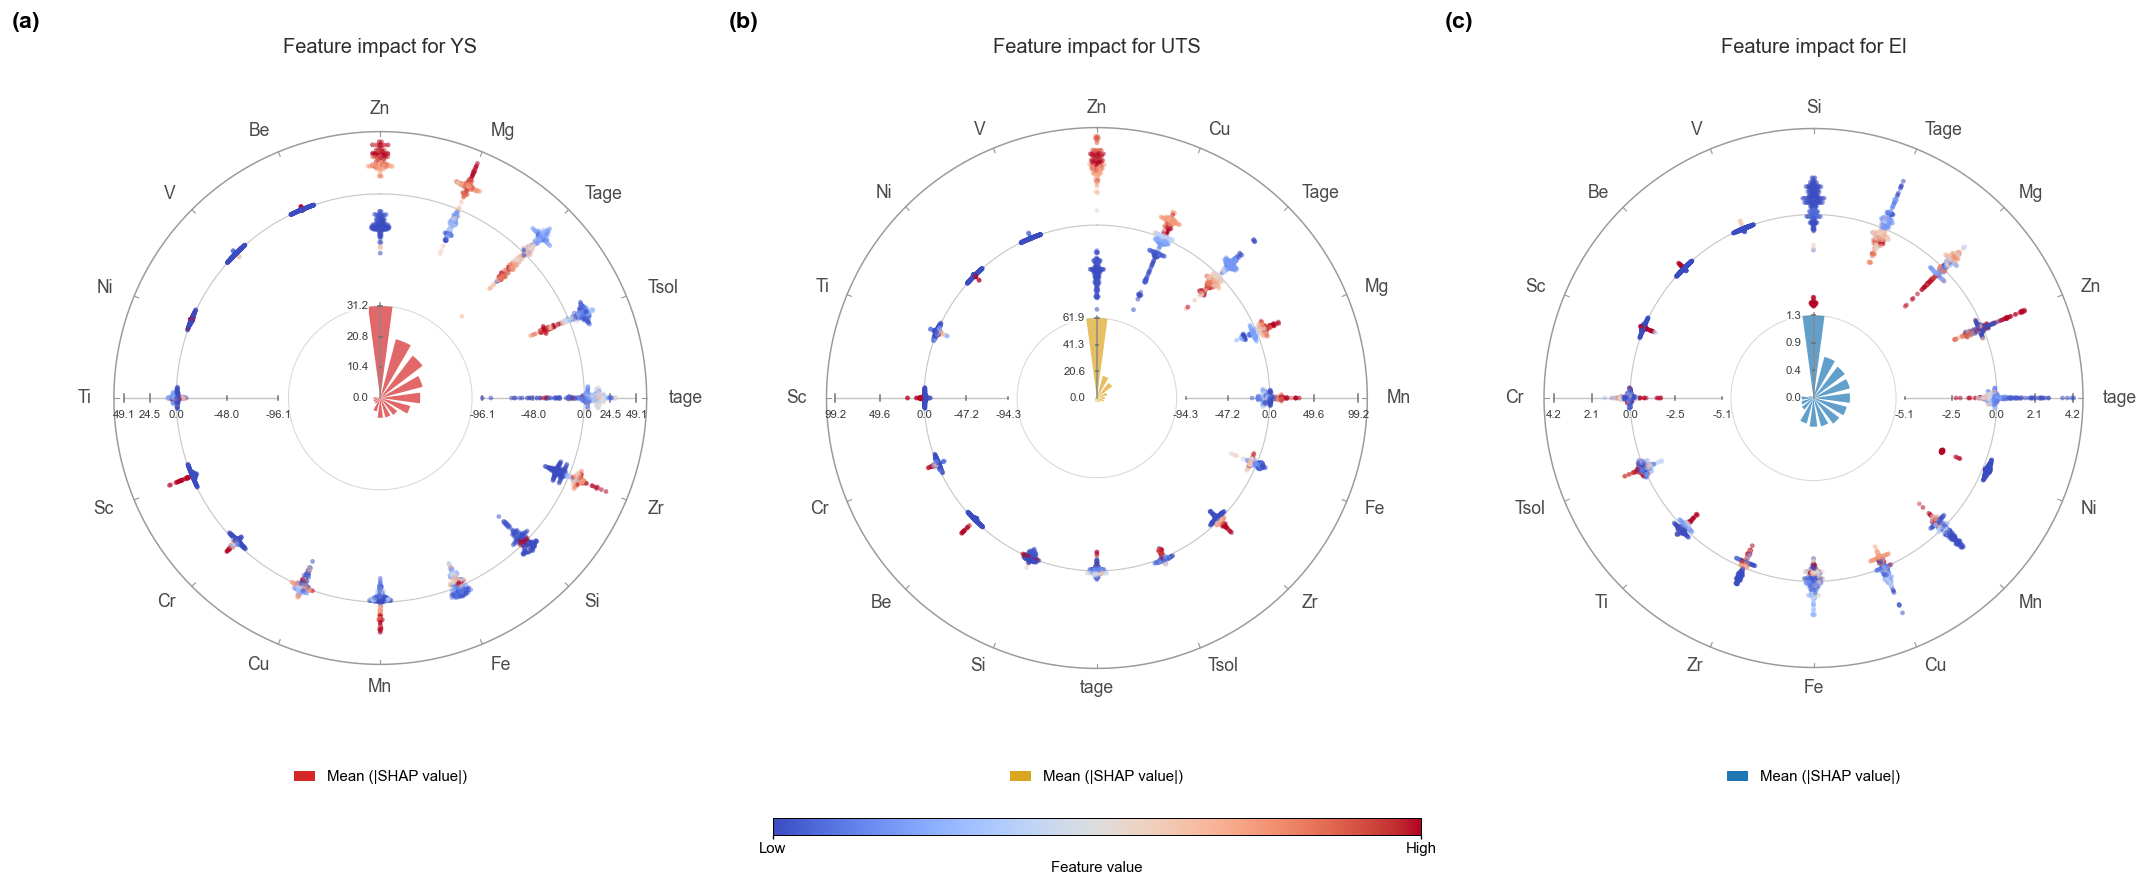

In [26]:

# ============================================================
# Cell 12：绘制 1×3 极坐标 SHAP 蜂巢图
# ============================================================
TARGET_CONFIG = [
    ('YS',  '#d62728', '(a)'),
    ('UTS', '#DAA520', '(b)'),
    ('El',  '#1f77b4', '(c)'),
]

fig = plt.figure(figsize=(18, 7.5))

for idx, (target, color, panel) in enumerate(TARGET_CONFIG):
    ax = fig.add_subplot(1, 3, idx + 1, projection='polar')
    res = shap_results[target]
    plot_one_polar(
        ax,
        res['sv'],
        res['X'],
        res['columns'],
        rose_color=color,
        panel_label=panel,
        target_label=target,
    )

cbar_ax = fig.add_axes([0.35, 0.065, 0.30, 0.018])
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.ax.tick_params(labelsize=9, length=2.5, pad=2)
cbar.outline.set_linewidth(0.6)
cbar.set_label('Feature value', fontsize=9, labelpad=3)

fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.22, wspace=0.20)

plt.savefig(SHAP_DIR / 'shap_polar_beeswarm_sci.png', dpi=600, transparent=True)
plt.savefig(SHAP_DIR / 'shap_polar_beeswarm_sci.pdf', dpi=600, transparent=True)
plt.savefig(SHAP_DIR / 'shap_polar_beeswarm_sci.svg', transparent=True)
plt.show()
